# Binary Data 

In [3]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [4]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'binary_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

        
    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)


    results_by_label = {
        "EA-Base": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


load_results(subset)
long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df[""]]



## Collider 

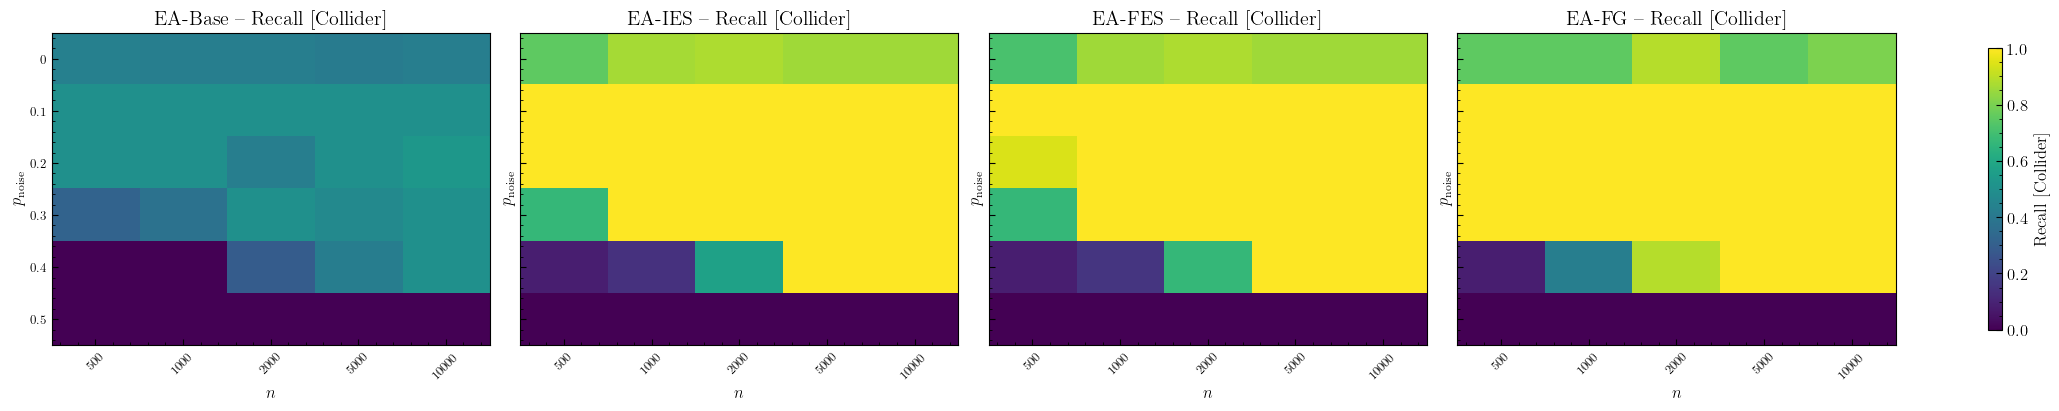

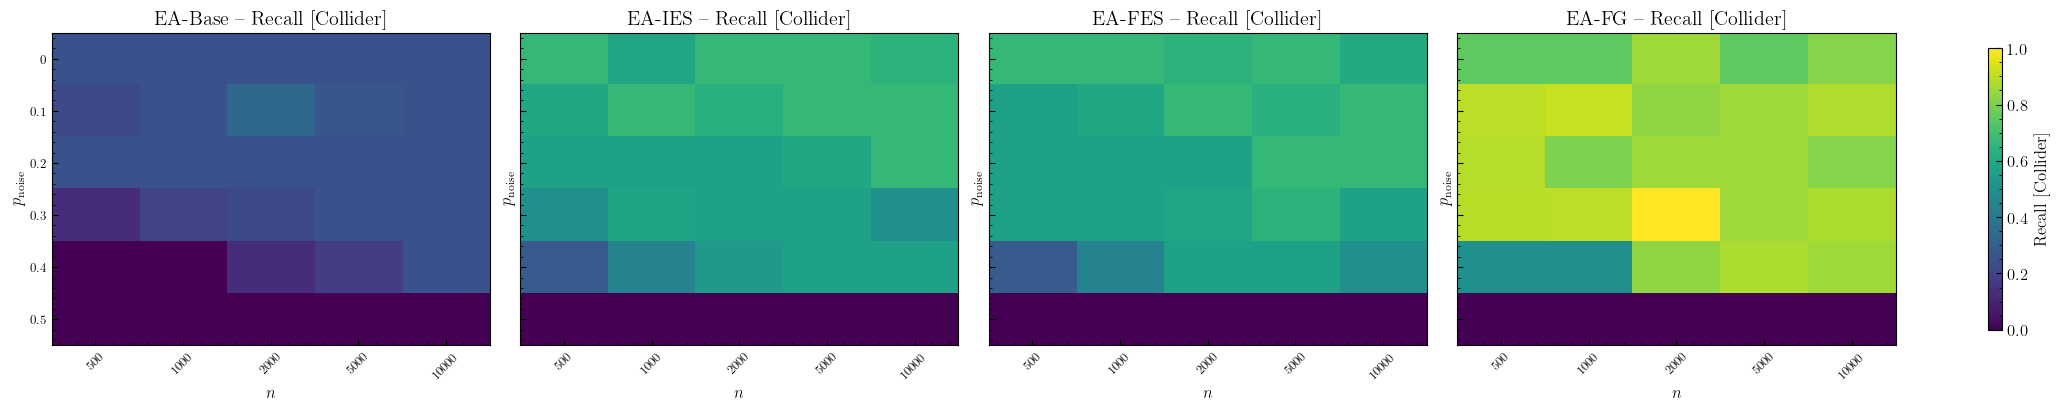

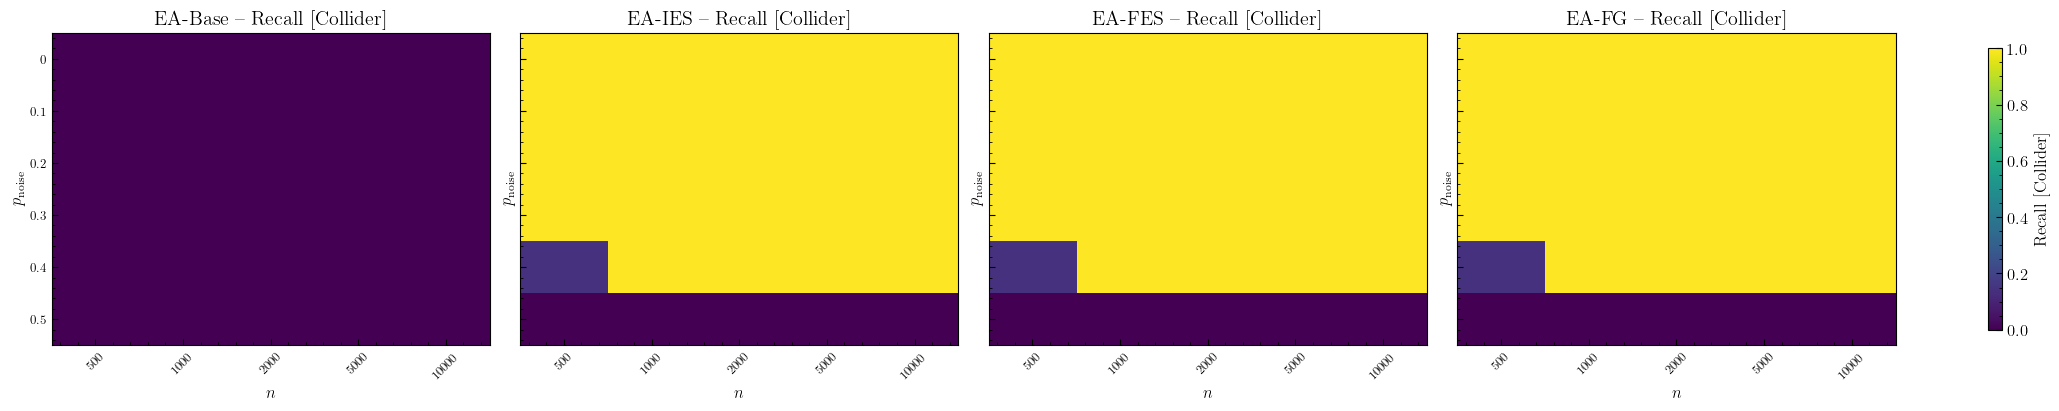

In [12]:
load_results("binary_data")
plot_results = {k: results_by_label[k] for k in ["EA-Base", "EA-IES", "EA-FES", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

metric = "Recall [Collider]"
x_col = "samples"
y_col = "p_noise"

filters = [("p_syn", 0), ("p_syn", 0.5), ("p_syn", 1)]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        sub_df,
        # mapping=mapping,
        ncols=5,
        plot_metric=metric,
        x_col=x_col,
        aggfunc="median",
        filter=(filter_col, filter_val),
        y_col=y_col,
        x_label=f"$n$",
        y_label=r"$p_{\mathrm{noise}}$",
    )    
    plt.savefig(f"Figures/AblationStudy/Binary_Fig1_{i}.png", bbox_inches='tight')
    i += 1
   

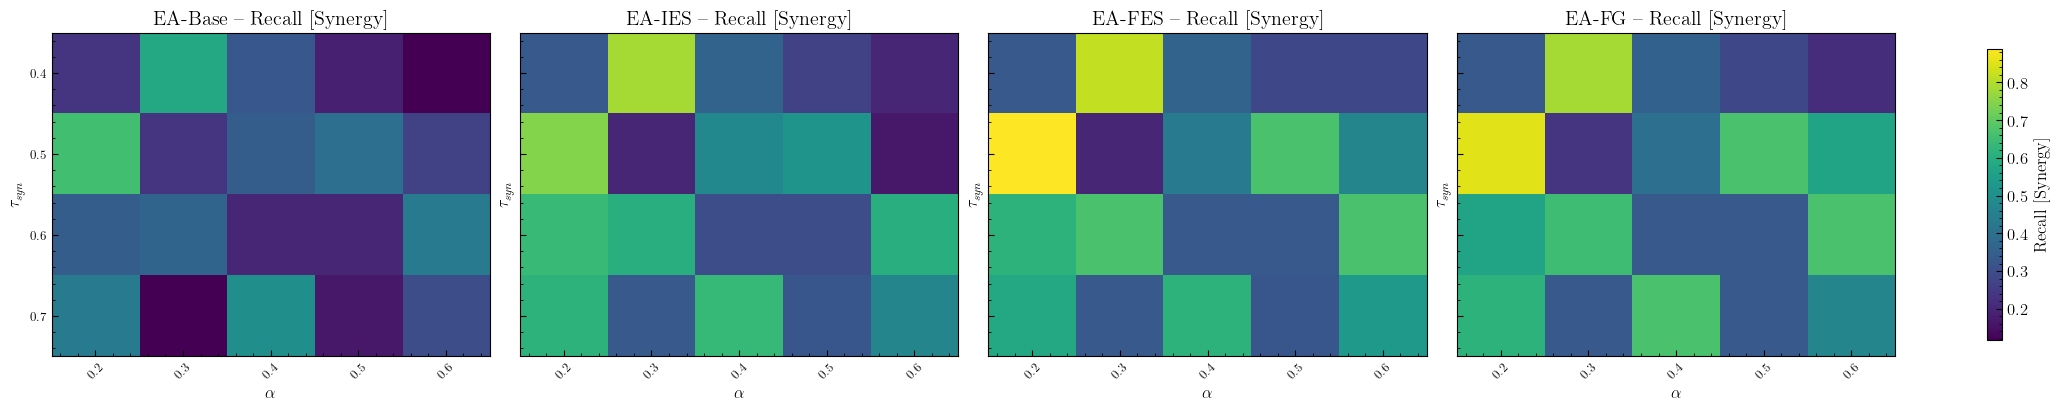

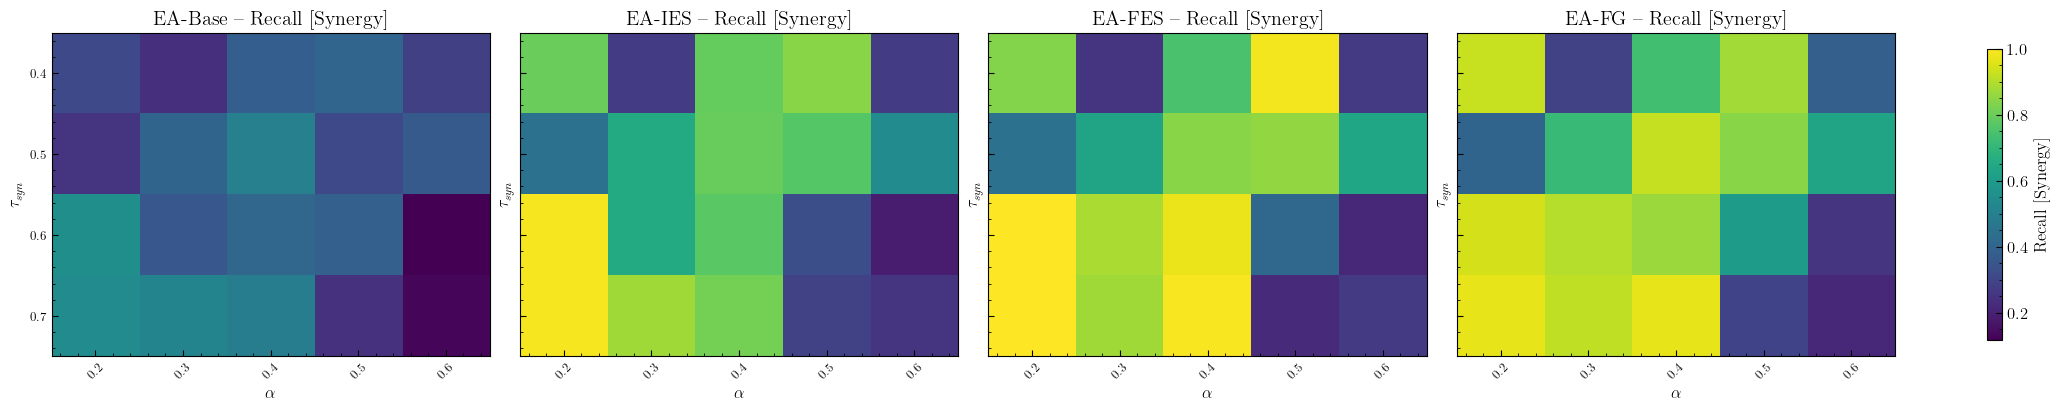

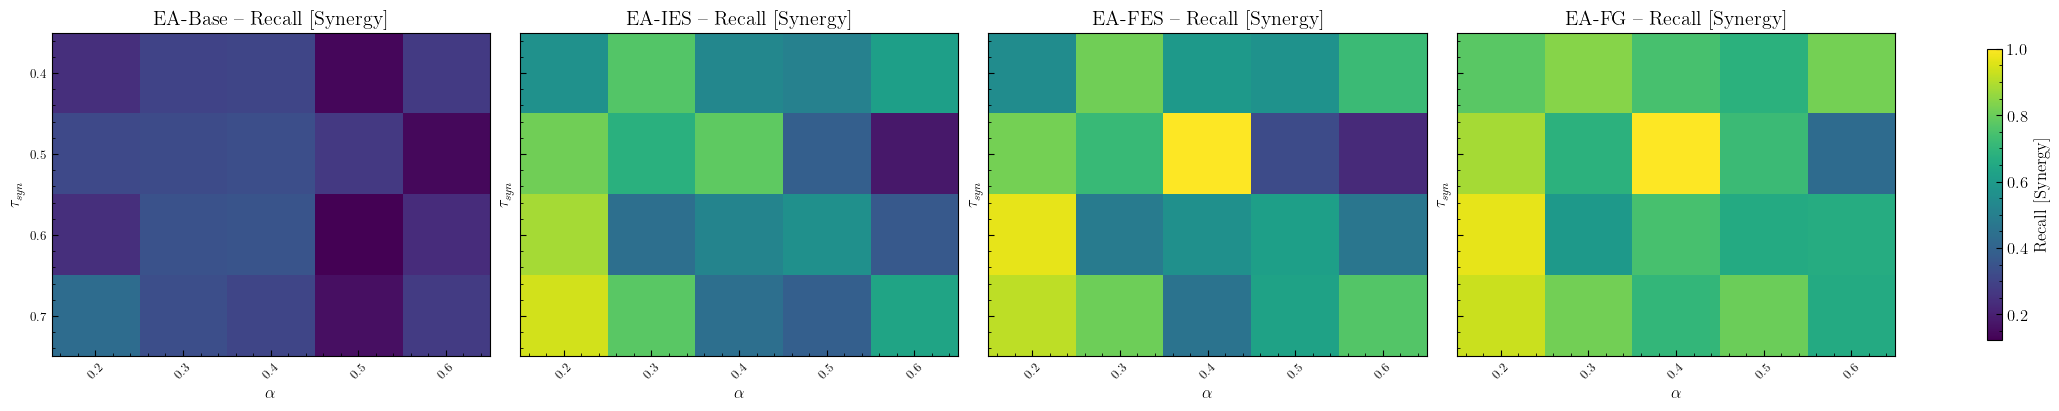

In [13]:
# metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]
load_results("jpmf_data")

plot_results = {k: results_by_label[k] for k in ["EA-Base", "EA-IES", "EA-FES", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

# sub_df = sub_df[sub_df["Total (SC)"] > 0]
sub_df = sub_df[sub_df["pair_probs"] == 0.7]

metric = "Recall [Synergy]"
x_col = "target_mi"
y_col = "syn_cutoff"


filters = [("num_vars", 10), ("num_vars", 20), ("num_vars", 30)]

# filters = [("pair_probs", )]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        sub_df,
        ncols=5,
        # subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )  
    for a in axes:
        # for a in ax:
        a.set_ylabel(r"$\tau_{syn}$")
        a.set_xlabel(r"$\alpha$")
        labels = [0.20, 0.30, 0.40, 0.50, 0.60]
        a.set_xticks(range(len(labels)))
        a.set_xticklabels(labels)
            
    plt.savefig(f"Figures/AblationStudy/JPMF_Fig1_{i}.png", bbox_inches='tight')
    i += 1
#    

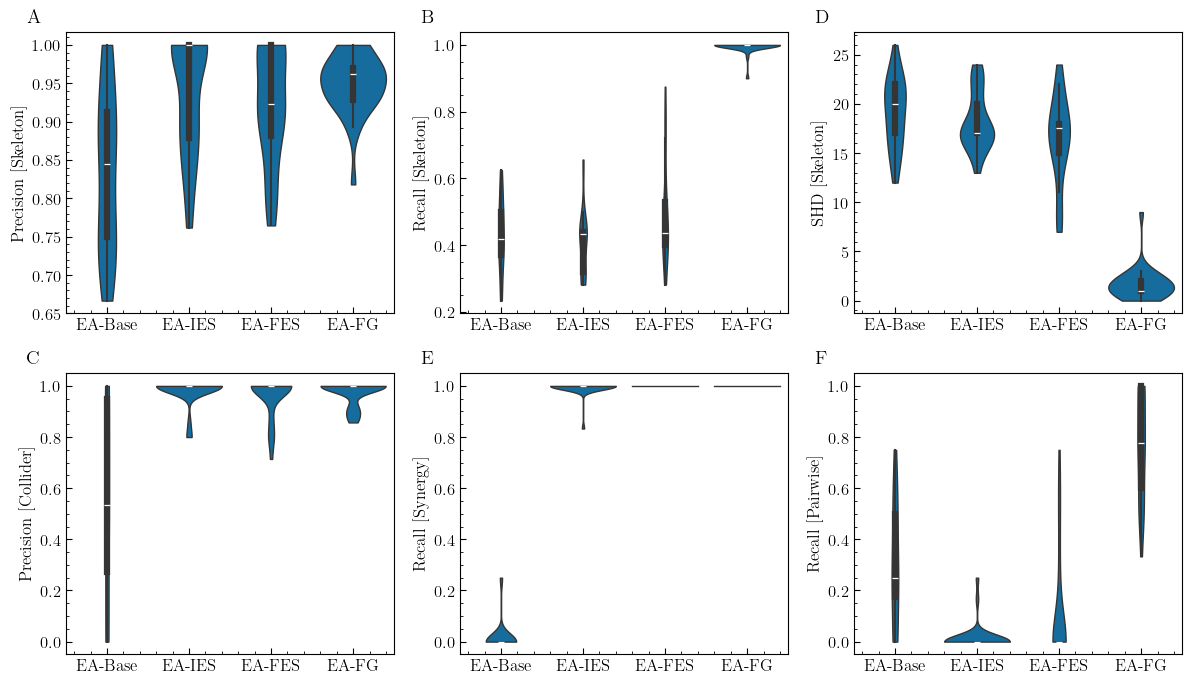

In [14]:
load_results("binary_data")
plot_results = {k: results_by_label[k] for k in ["EA-Base", "EA-IES", "EA-FES", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["EA-Base", "EA-IES", "EA-FES", "EA-FG"] 

# Example slice (optional):
filter_dict = {"p_syn": 0.5, "p_noise": 0.3, "samples": 10_000, "total_vars": 30}
# filter_dict = None

fig, axes = violin_grid_2x2(
    sub_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(12, 7),
)

plt.savefig(
    f"Figures/AblationStudy/Binary_Fig2.png",
    dpi=800,
)


In [28]:
sub_df.columns

Index(['n_nodes', 'n_pairs', 'SHD [Skeleton]', 'Type Confusions [Adjacency]',
       'n_true [Adjacency]', 'n_pred [Adjacency]', 'TP [Adjacency]',
       'FP [Adjacency]', 'FN [Adjacency]', 'Precision [Skeleton]',
       'Recall [Skeleton]', 'F1 [Skeleton]', 'TP (Found Colliders)',
       'FP (Extra Colliders)', 'FN (Missing Colliders )',
       'TP (Synergistic Colliders Found)',
       'FN (Missing Synergistic Colliders)', 'Precision [Collider]',
       'Recall [Collider]', 'F1 [Collider]', 'Precision [Synergy]',
       'Recall [Synergy]', 'F1 [Synergy]', 'TP (Pairwise Colliders Found)',
       'FN (Missing Pairwise Colliders)', 'Precision [Pairwise]',
       'Recall [Pairwise]', 'F1 [Pairwise]', 'i', 'family', 'target_mi',
       'pair_probs', 'syn_cutoff', 'num_vars', 'TrueBIC', 'BIC', 'WallTime_s',
       'CPUTime_s', 'RSS_before_MB', 'RSS_after_MB', 'RSS_delta_MB',
       'PeakRSS_MB', 'PyAllocPeak_MB', 'Algorithm', 'run_id',
       'Total (Colliders)', 'TP (Synergy)', 'FN (Syner

In [34]:
sub_df.columns

Index(['n_nodes', 'n_pairs', 'SHD [Skeleton]', 'Type Confusions [Adjacency]',
       'n_true [Adjacency]', 'n_pred [Adjacency]', 'TP [Adjacency]',
       'FP [Adjacency]', 'FN [Adjacency]', 'Precision [Skeleton]',
       'Recall [Skeleton]', 'F1 [Skeleton]', 'TP (Found Colliders)',
       'FP (Extra Colliders)', 'FN (Missing Colliders )',
       'TP (Synergistic Colliders Found)',
       'FN (Missing Synergistic Colliders)', 'Precision [Collider]',
       'Recall [Collider]', 'F1 [Collider]', 'Precision [Synergy]',
       'Recall [Synergy]', 'F1 [Synergy]', 'TP (Pairwise Colliders Found)',
       'FN (Missing Pairwise Colliders)', 'Precision [Pairwise]',
       'Recall [Pairwise]', 'F1 [Pairwise]', 'i', 'family', 'target_mi',
       'pair_probs', 'syn_cutoff', 'num_vars', 'TrueBIC', 'BIC', 'WallTime_s',
       'CPUTime_s', 'RSS_before_MB', 'RSS_after_MB', 'RSS_delta_MB',
       'PeakRSS_MB', 'PyAllocPeak_MB', 'Algorithm', 'run_id',
       'Total (Colliders)', 'TP (Synergy)', 'FN (Syner

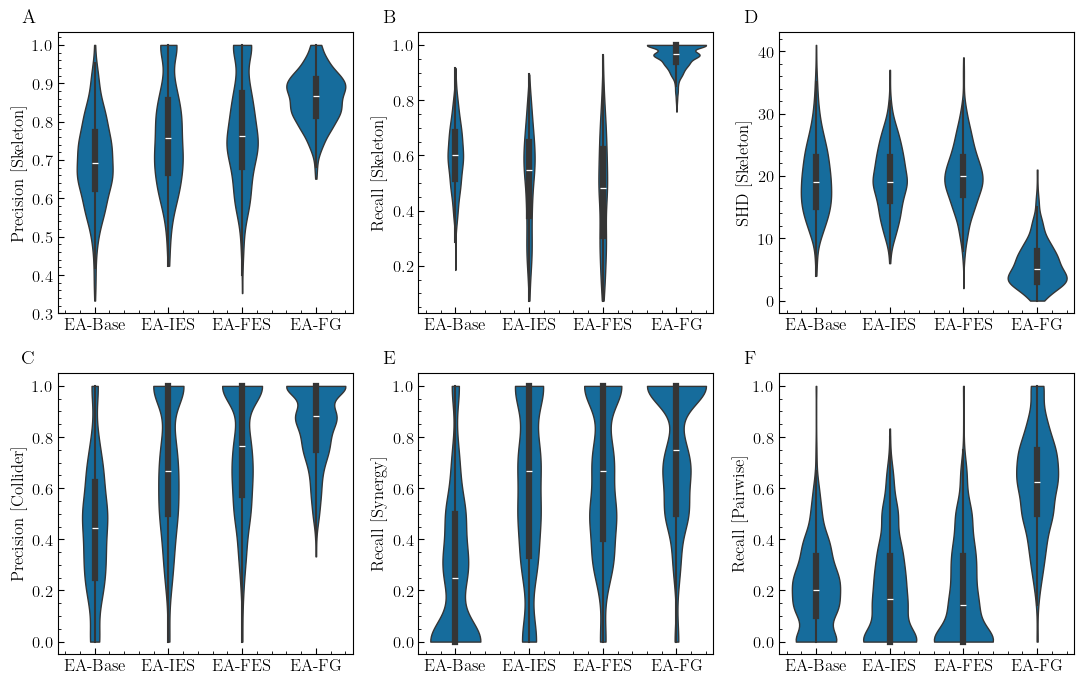

In [41]:
load_results("jpmf_data")

plot_results = {k: results_by_label[k] for k in ["EA-Base", "EA-IES", "EA-FES", "EA-FG"]}
sub_df = build_long_metrics(plot_results)
# sub_df = sub_df[sub_df["Total (SC)"] > 0 & (sub_df["Total (PW)"] > 0)]

metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["EA-Base", "EA-IES", "EA-FES", "EA-FG"] 

# Example slice (optional):
filter_dict = {"num_vars": 30, "pair_probs": 0.7}
# filter_dict = None

fig, axes = violin_grid_2x2(
    sub_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(11, 7),
)

plt.savefig(
    f"Figures/AblationStudy/JPMF_Fig2.png",
    dpi=800,
)


In [39]:
sub_df["num_vars"].unique()

array([10, 20, 30], dtype=object)